# Supervised Learning:  Welding Quality Prediction System
---
This notebook performs a detailed analysis and predictive modeling of weld mechanical properties based on chemical composition and welding parameters. The goal is to build machine learning models that can predict key mechanical properties of welds from input features.

## 1. Loading the data

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv('cleandata_V1 (2).csv')

## 2. Initial Data Exploration

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 45 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 1639 non-null   int64  
 1   Carbon concentration (weight%)             1639 non-null   float64
 2   Silicon concentration (weight%)            1639 non-null   float64
 3   Manganese concentration (weight%)          1639 non-null   float64
 4   Sulphur concentration (weight%)            1639 non-null   float64
 5   Phosphorus concentration (weight%)         1639 non-null   float64
 6   Nickel concentration (weight%)             1639 non-null   float64
 7   Chromium concentration (weight%)           1639 non-null   float64
 8   Molybdenum concentration (weight%)         1639 non-null   float64
 9   Vanadium concentration (weight%)           1639 non-null   float64
 10  Copper concentration (we

In [ ]:
df["Charpy temperature (°C)"]=df["Charpy temperature (°C)"].replace(-1,np.nan)

In [ ]:
df["Charpy impact toughness (J)"]=df["Charpy impact toughness (J)"].replace(-1,np.nan)

Drops columns with extremely high missing values (>90% missing):
  - Hardness measurements
  - Microstructural properties
  - Weld ID (identifier, not predictive)
- This reduces dimensionality from 45 to 37 columns while retaining the most informative features.

In [ ]:
df.drop(["Hardness (kgmm-2)",'Acicular ferrite (%)',"50% FATT","Primary ferrite in microstructure (%)","Ferrite with second phase (%)","Martensite (%)","Ferrite with carbide aggregate (%)","Weld ID"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 37 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 1639 non-null   int64  
 1   Carbon concentration (weight%)             1639 non-null   float64
 2   Silicon concentration (weight%)            1639 non-null   float64
 3   Manganese concentration (weight%)          1639 non-null   float64
 4   Sulphur concentration (weight%)            1639 non-null   float64
 5   Phosphorus concentration (weight%)         1639 non-null   float64
 6   Nickel concentration (weight%)             1639 non-null   float64
 7   Chromium concentration (weight%)           1639 non-null   float64
 8   Molybdenum concentration (weight%)         1639 non-null   float64
 9   Vanadium concentration (weight%)           1639 non-null   float64
 10  Copper concentration (we

- **Features columns (40 variables):** Chemical compositions, welding parameters, process variables
- **Mechanical properties (4 targets):** Yield strength, Ultimate tensile strength, Elongation, Reduction of Area
- **Charpy properties (1 target):** Impact toughness

In [ ]:
features_cols = [
    "Carbon concentration (weight%)",
    "Silicon concentration (weight%)",
    "Manganese concentration (weight%)",
    "Sulphur concentration (weight%)",
    "Phosphorus concentration (weight%)",
    "Nickel concentration (weight%)",
    "Chromium concentration (weight%)",
    "Molybdenum concentration (weight%)",
    "Vanadium concentration (weight%)",
    "Copper concentration (weight%)",
    "Cobalt concentration (weight%)",
    "Tungsten concentration (weight%)",
    "Oxygen concentration (ppm by weight)",
    "Titanium concentration (ppm by weight)",
    "Nitrogen concentration (ppm by weight)",
    "Aluminium concentration (ppm by weight)",
    "Boron concentration (ppm by weight)",
    "Niobium concentration (ppm by weight)",
    "Tin concentration (ppm by weight)",
    "Arsenic concentration (ppm by weight)",
    "Antimony concentration (ppm by weight)",
    "Current (A)",
    "Voltage (V)",
    "AC or DC",
    "Electrode polarity (positive or negative)",
    "Heat input (kJmm-1)",
    "Interpass temperature (°C)",
    "Type of weld",
    "Post weld heat treatment temperature (°C)",
    "Post weld heat treatment time (hours)","Charpy temperature (°C)"
]


In [ ]:
mechanical_cols = [
    "Yield strength (MPa)",
    "Ultimate tensile strength (MPa)",
    "Elongation (%)",
    "Reduction of Area (%)"
]

charpy_cols = [
    "Charpy impact toughness (J)"
]

### Missing value analysis

A more thorough analysis and explained is in the preprocessing notebook:`Welding_Quality_Preprocessing.ipynb`

we can see that   
  - Mechanical properties: ~50-58% missing data
  - Charpy properties: ~46% missing data
  - 840 samples have NO mechanical properties
  - 650 samples have ALL mechanical properties
  - Charpy properties appear together (879 samples have both temperature and toughness)

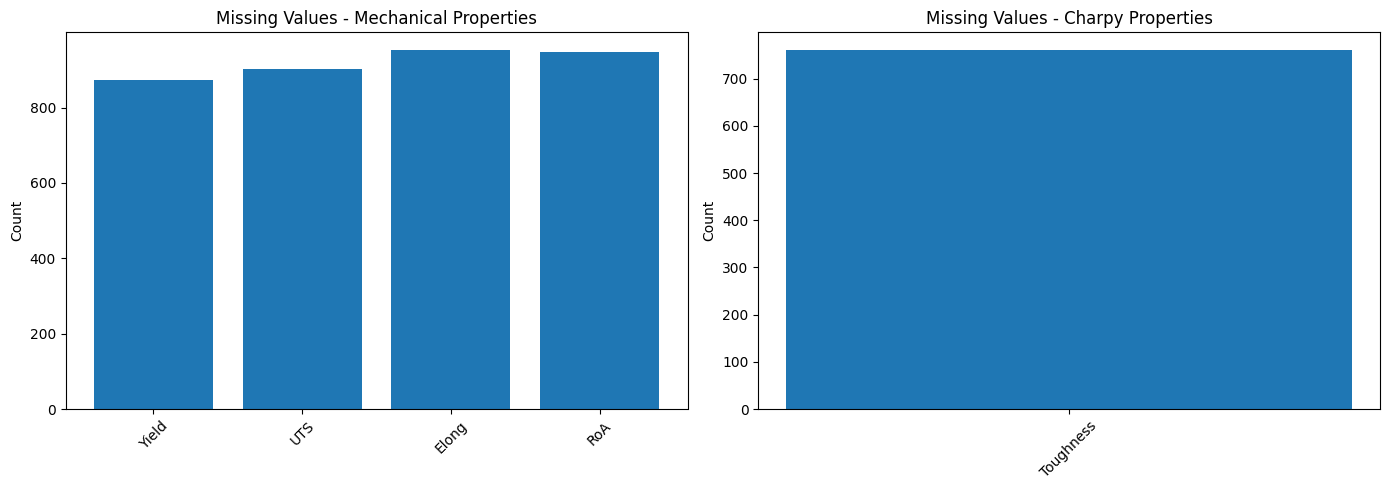


=== STATISTIQUES MISSING VALUES ===

MECHANICAL PROPERTIES:
  Yield strength (MPa): 767 disponibles, 872 manquants (53.2%)
  Ultimate tensile strength (MPa): 738 disponibles, 901 manquants (55.0%)
  Elongation (%): 687 disponibles, 952 manquants (58.1%)
  Reduction of Area (%): 692 disponibles, 947 manquants (57.8%)

Distribution des propriétés mécaniques disponibles:
mech_count
0    840
1     63
2     37
3     49
4    650
Name: count, dtype: int64

CHARPY PROPERTIES:
  Charpy impact toughness (J): 879 disponibles, 760 manquants (46.4%)

Charpy: 879 avec les 2 valeurs, 760 avec 0 valeur


In [ ]:
 Visualiser les valeurs manquantes
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mechanical properties
mech_missing = df[mechanical_cols].isnull().sum()
axes[0].bar(range(len(mech_missing)), mech_missing.values)
axes[0].set_xticks(range(len(mech_missing)))
axes[0].set_xticklabels(['Yield', 'UTS', 'Elong', 'RoA'], rotation=45)
axes[0].set_title('Missing Values - Mechanical Properties')
axes[0].set_ylabel('Count')

# Charpy properties
charpy_missing = df[charpy_cols].isnull().sum()
axes[1].bar(range(len(charpy_missing)), charpy_missing.values)
axes[1].set_xticks(range(len(charpy_missing)))
axes[1].set_xticklabels([ 'Toughness'], rotation=45)
axes[1].set_title('Missing Values - Charpy Properties')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Statistiques détaillées
print("\n=== STATISTIQUES MISSING VALUES ===\n")

# Mechanical
print("MECHANICAL PROPERTIES:")
for col in mechanical_cols:
    missing = df[col].isnull().sum()
    available = df[col].notna().sum()
    print(f"  {col}: {available} disponibles, {missing} manquants ({missing/len(df)*100:.1f}%)")

# Compter les patterns de missing dans mechanical
df['mech_count'] = df[mechanical_cols].notna().sum(axis=1)
print(f"\nDistribution des propriétés mécaniques disponibles:")
print(df['mech_count'].value_counts().sort_index())

# Charpy
print("\nCHARPY PROPERTIES:")
for col in charpy_cols:
    missing = df[col].isnull().sum()
    available = df[col].notna().sum()
    print(f"  {col}: {available} disponibles, {missing} manquants ({missing/len(df)*100:.1f}%)")

# Vérifier si Charpy toujours ensemble
charpy_both = df[charpy_cols].notna().all(axis=1).sum()
charpy_none = df[charpy_cols].isnull().all(axis=1).sum()
print(f"\nCharpy: {charpy_both} avec les 2 valeurs, {charpy_none} avec 0 valeur")

## Categorical Variable Analysis

In [ ]:
df["AC or DC"].value_counts()

,count
AC or DC,
DC,1597
AC,42


In [ ]:
df["Electrode polarity (positive or negative)"].value_counts()

,count
Electrode polarity (positive or negative),
+,1594
0,38
-,7


**Encoding categorical variables:**
  - AC/DC: AC→0, DC→1
  - Electrode polarity: +→1, 0→0, -→-1
  - Weld type: One-hot encoded into multiple binary columns

In [ ]:
df_encoded = df.copy()

if "AC or DC" in df.columns:
    df_encoded["AC or DC"] = df_encoded["AC or DC"].map({'AC': 0, 'DC': 1})

In [ ]:
if "Electrode polarity (positive or negative)" in df.columns:
    df_encoded["Electrode polarity (positive or negative)"] = df_encoded["Electrode polarity (positive or negative)"].map({'+': 1, '0': 0,'-':-1})


In [ ]:
if "Type of weld" in df.columns:
    df_encoded = pd.get_dummies(df_encoded, columns=["Type of weld"], prefix="weld_type")
    features_cols = [col for col in df_encoded.columns if col.startswith('weld_type') or col in features_cols]


## 3. Prediction model

In [ ]:
X = df_encoded[features_cols].copy()
y_mechanical = df_encoded[mechanical_cols].copy()
y_charpy = df_encoded[charpy_cols].copy()


In [ ]:
print(f" X shape: {X.shape}")
print(f" y_mechanical shape: {y_mechanical.shape}")
print(f" y_charpy shape: {y_charpy.shape}")

 X shape: (1639, 40)
 y_mechanical shape: (1639, 4)
 y_charpy shape: (1639, 1)


In [ ]:
df_encoded.to_csv('cealnwelddata.csv')

Analyse des Corrélations

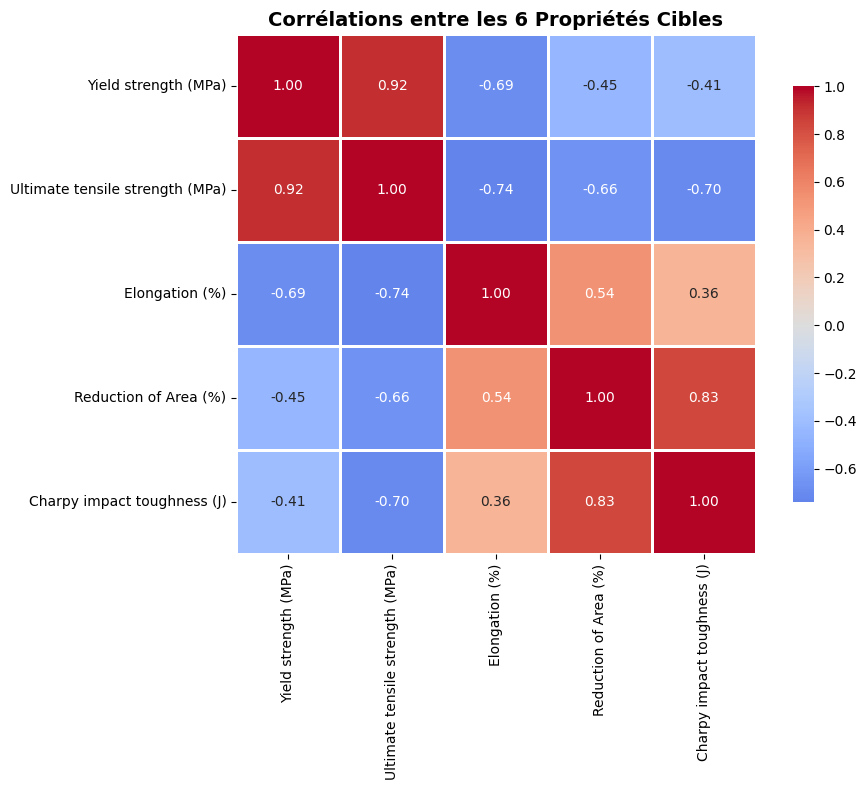


=== CORRÉLATIONS IMPORTANTES ===
Yield strength (MPa) ↔ Ultimate tensile strength (MPa): 0.915
Ultimate tensile strength (MPa) ↔ Elongation (%): -0.739
Ultimate tensile strength (MPa) ↔ Charpy impact toughness (J): -0.702
Reduction of Area (%) ↔ Charpy impact toughness (J): 0.831


In [ ]:
# Créer un dataset avec toutes les targets disponibles
df_complete = pd.concat([X, y_mechanical, y_charpy], axis=1)

# Matrice de corrélation entre les 6 targets
targets_all = mechanical_cols + charpy_cols
corr_targets = df_complete[targets_all].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_targets, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Corrélations entre les 6 Propriétés Cibles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== CORRÉLATIONS IMPORTANTES ===")
# Trouver les corrélations > 0.7
for i in range(len(targets_all)):
    for j in range(i+1, len(targets_all)):
        corr_val = corr_targets.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"{targets_all[i]} ↔ {targets_all[j]}: {corr_val:.3f}")

In [ ]:
def train_and_evaluate_model(X_train, X_test, y_train, y_test, target_name, model_type='rf'):
    """
    Entraîne un modèle et retourne les métriques

    model_type: 'rf' (Random Forest) ou 'gb' (Gradient Boosting)
    """
    # Ignorer les lignes avec missing dans y_train pour cette target
    mask_train = y_train.notna()
    X_train_clean = X_train[mask_train]
    y_train_clean = y_train[mask_train]

    mask_test = y_test.notna()
    X_test_clean = X_test[mask_test]
    y_test_clean = y_test[mask_test]



    # Choisir le modèle
    if model_type == 'rf':
        model = RandomForestRegressor(n_estimators=100, max_depth=15,
                                     min_samples_split=5, random_state=42, n_jobs=-1)
    else:  # 'gb'
        model = GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                         learning_rate=0.1, random_state=42)

    # Entraîner
    model.fit(X_train_clean, y_train_clean)

    # Prédire
    y_pred = model.predict(X_test_clean)

    # Métriques
    mae = mean_absolute_error(y_test_clean, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
    r2 = r2_score(y_test_clean, y_pred)

    # Erreur relative moyenne
    mape = np.mean(np.abs((y_test_clean - y_pred) / y_test_clean)) * 100

    results = {
        'model': model,
        'target': target_name,
        'n_train': len(y_train_clean),
        'n_test': len(y_test_clean),
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'y_test': y_test_clean,
        'y_pred': y_pred
    }

    return results


In [ ]:
X_train, X_test, y_mech_train, y_mech_test, y_charpy_train, y_charpy_test = train_test_split(
    X, y_mechanical, y_charpy, test_size=0.2, random_state=42
)


In [ ]:
print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")


Train set: 1311 samples
Test set: 328 samples


Split Train/Test

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


In [ ]:

results_mechanical = {}

for col in mechanical_cols:
    print(f"\nTraining pour: {col}")

    result = train_and_evaluate_model(
        X_train_scaled, X_test_scaled,
        y_mech_train[col], y_mech_test[col],
        col, model_type='rf'
    )

    if result:
        results_mechanical[col] = result
        print(f"  Train samples: {result['n_train']}")
        print(f"  Test samples: {result['n_test']}")
        print(f"  MAE: {result['mae']:.2f}")
        print(f"  RMSE: {result['rmse']:.2f}")
        print(f"  R²: {result['r2']:.3f}")
        print(f"  MAPE: {result['mape']:.2f}%")


Training pour: Yield strength (MPa)
  Train samples: 607
  Test samples: 160
  MAE: 31.19
  RMSE: 45.46
  R²: 0.766
  MAPE: 5.90%

Training pour: Ultimate tensile strength (MPa)
  Train samples: 586
  Test samples: 152
  MAE: 24.70
  RMSE: 39.92
  R²: 0.836
  MAPE: 3.84%

Training pour: Elongation (%)
  Train samples: 542
  Test samples: 145
  MAE: 1.85
  RMSE: 2.30
  R²: 0.759
  MAPE: 7.68%

Training pour: Reduction of Area (%)
  Train samples: 547
  Test samples: 145
  MAE: 2.47
  RMSE: 5.20
  R²: 0.676
  MAPE: 5.26%


In [ ]:
results_charpy = {}

for col in charpy_cols:
    print(f"\n Training pour: {col}")

    result = train_and_evaluate_model(
        X_train_scaled, X_test_scaled,
        y_charpy_train[col], y_charpy_test[col],
        col, model_type='gb'
    )

    if result:
        results_charpy[col] = result
        print(f"  Train samples: {result['n_train']}")
        print(f"  Test samples: {result['n_test']}")
        print(f"  MAE: {result['mae']:.2f}")
        print(f"  RMSE: {result['rmse']:.2f}")
        print(f"  R²: {result['r2']:.3f}")
        print(f"  MAPE: {result['mape']:.2f}%")

print("\n Entraînement terminé pour les propriétés Charpy")


 Training pour: Charpy impact toughness (J)
  Train samples: 708
  Test samples: 171
  MAE: 11.66
  RMSE: 16.85
  R²: 0.900
  MAPE: 28.40%

 Entraînement terminé pour les propriétés Charpy


In [ ]:
# Créer un DataFrame avec tous les résultats
summary_data = []

for col, res in results_mechanical.items():
    summary_data.append({
        'Propriété': col.replace(' (MPa)', '').replace(' (%)', ''),
        'Type': 'Mechanical',
        'N_train': res['n_train'],
        'N_test': res['n_test'],
        'MAE': res['mae'],
        'RMSE': res['rmse'],
        'R²': res['r2'],
        'MAPE (%)': res['mape']
    })

for col, res in results_charpy.items():
    summary_data.append({
        'Propriété': col.replace(' (°C)', '').replace(' (J)', ''),
        'Type': 'Charpy',
        'N_train': res['n_train'],
        'N_test': res['n_test'],
        'MAE': res['mae'],
        'RMSE': res['rmse'],
        'R²': res['r2'],
        'MAPE (%)': res['mape']
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("RÉSUMÉ DES PERFORMANCES")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


RÉSUMÉ DES PERFORMANCES
                Propriété       Type  N_train  N_test       MAE      RMSE       R²  MAPE (%)
           Yield strength Mechanical      607     160 31.186990 45.458321 0.766205  5.895924
Ultimate tensile strength Mechanical      586     152 24.700464 39.918201 0.835985  3.841891
               Elongation Mechanical      542     145  1.847794  2.297240 0.759428  7.675627
        Reduction of Area Mechanical      547     145  2.467565  5.199009 0.675601  5.256722
  Charpy impact toughness     Charpy      708     171 11.661156 16.847613 0.900120 28.397952


From the performance summary, we can see that the models perform quite well overall. The R² values for yield strength (0.77), ultimate tensile strength (0.84), and elongation (0.76) indicate that the models explain a large portion of the variance in the data, with relatively low error margins (MAE between 1.8 and 31 depending on the property). The reduction of area shows slightly weaker performance (R² ≈ 0.68), suggesting it’s harder to predict, possibly due to higher experimental variability. Interestingly, the Charpy impact toughness model achieves the highest R² (0.90), showing excellent predictive power, although its MAPE (≈28%) is high, likely because the target values vary across a broad range. Overall, the results suggest that the compositional features are strong predictors of the mechanical behavior, with room for improvement on properties that are more sensitive to microstructural effects.

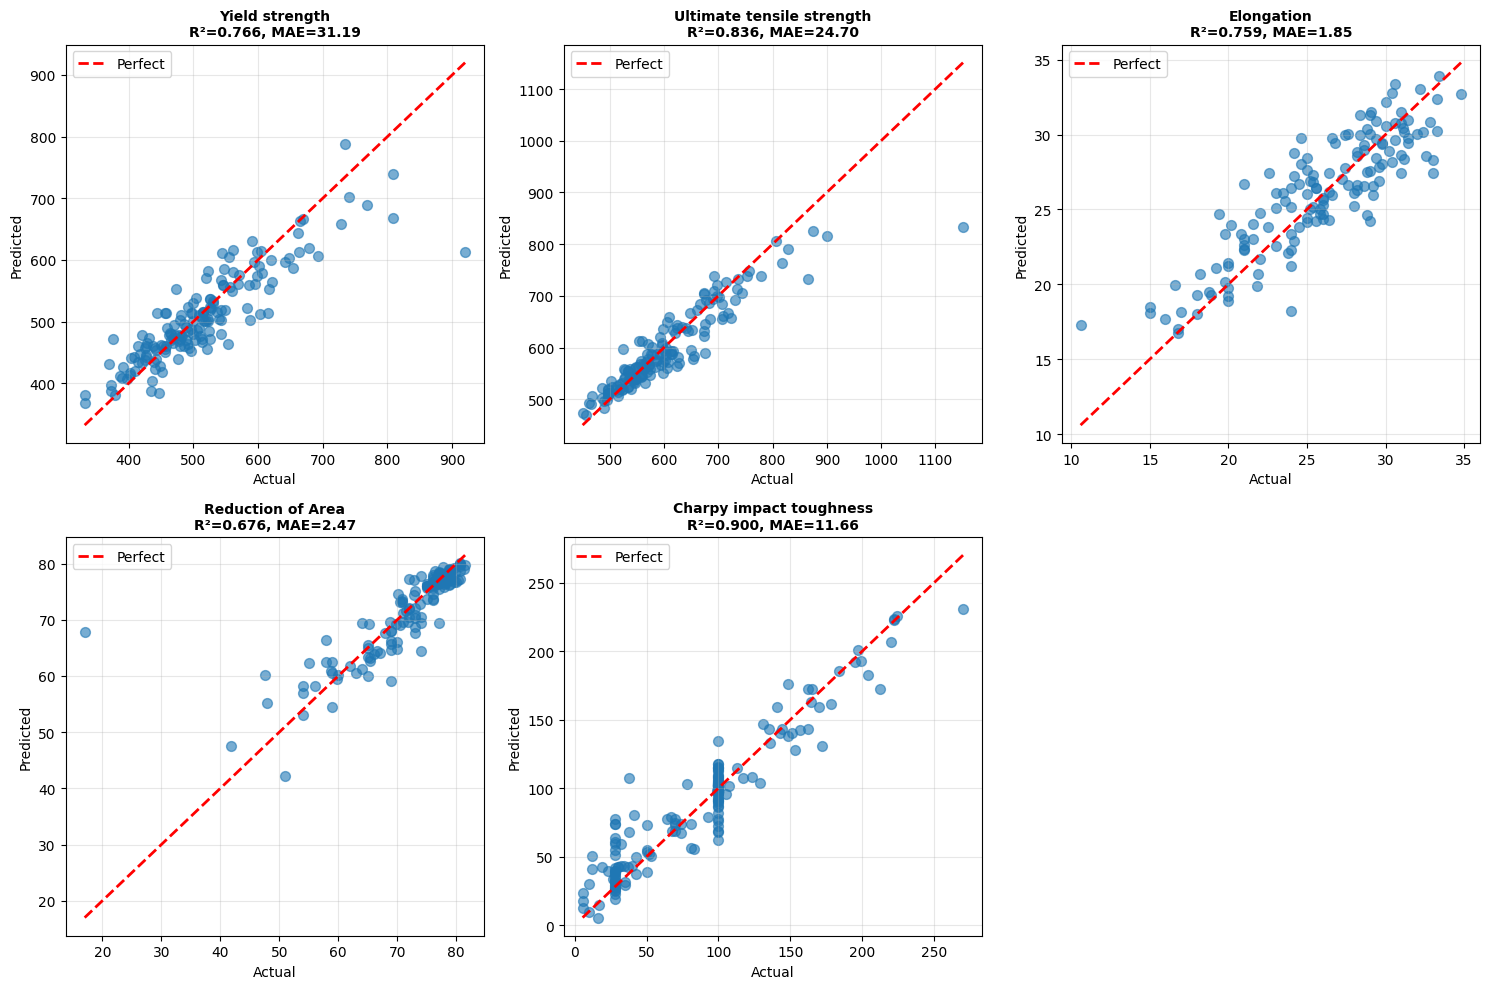

In [ ]:
# Graphiques Predicted vs Actual
all_results = {**results_mechanical, **results_charpy}
n_plots = len(all_results)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

for idx, (target, res) in enumerate(all_results.items()):
    ax = axes[idx]

    y_test = res['y_test']
    y_pred = res['y_pred']

    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.6, s=50)

    # Ligne parfaite
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')

    ax.set_xlabel('Actual', fontsize=10)
    ax.set_ylabel('Predicted', fontsize=10)
    ax.set_title(f"{target.split('(')[0].strip()}\nR²={res['r2']:.3f}, MAE={res['mae']:.2f}",
                 fontsize=10, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Cacher les axes vides
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

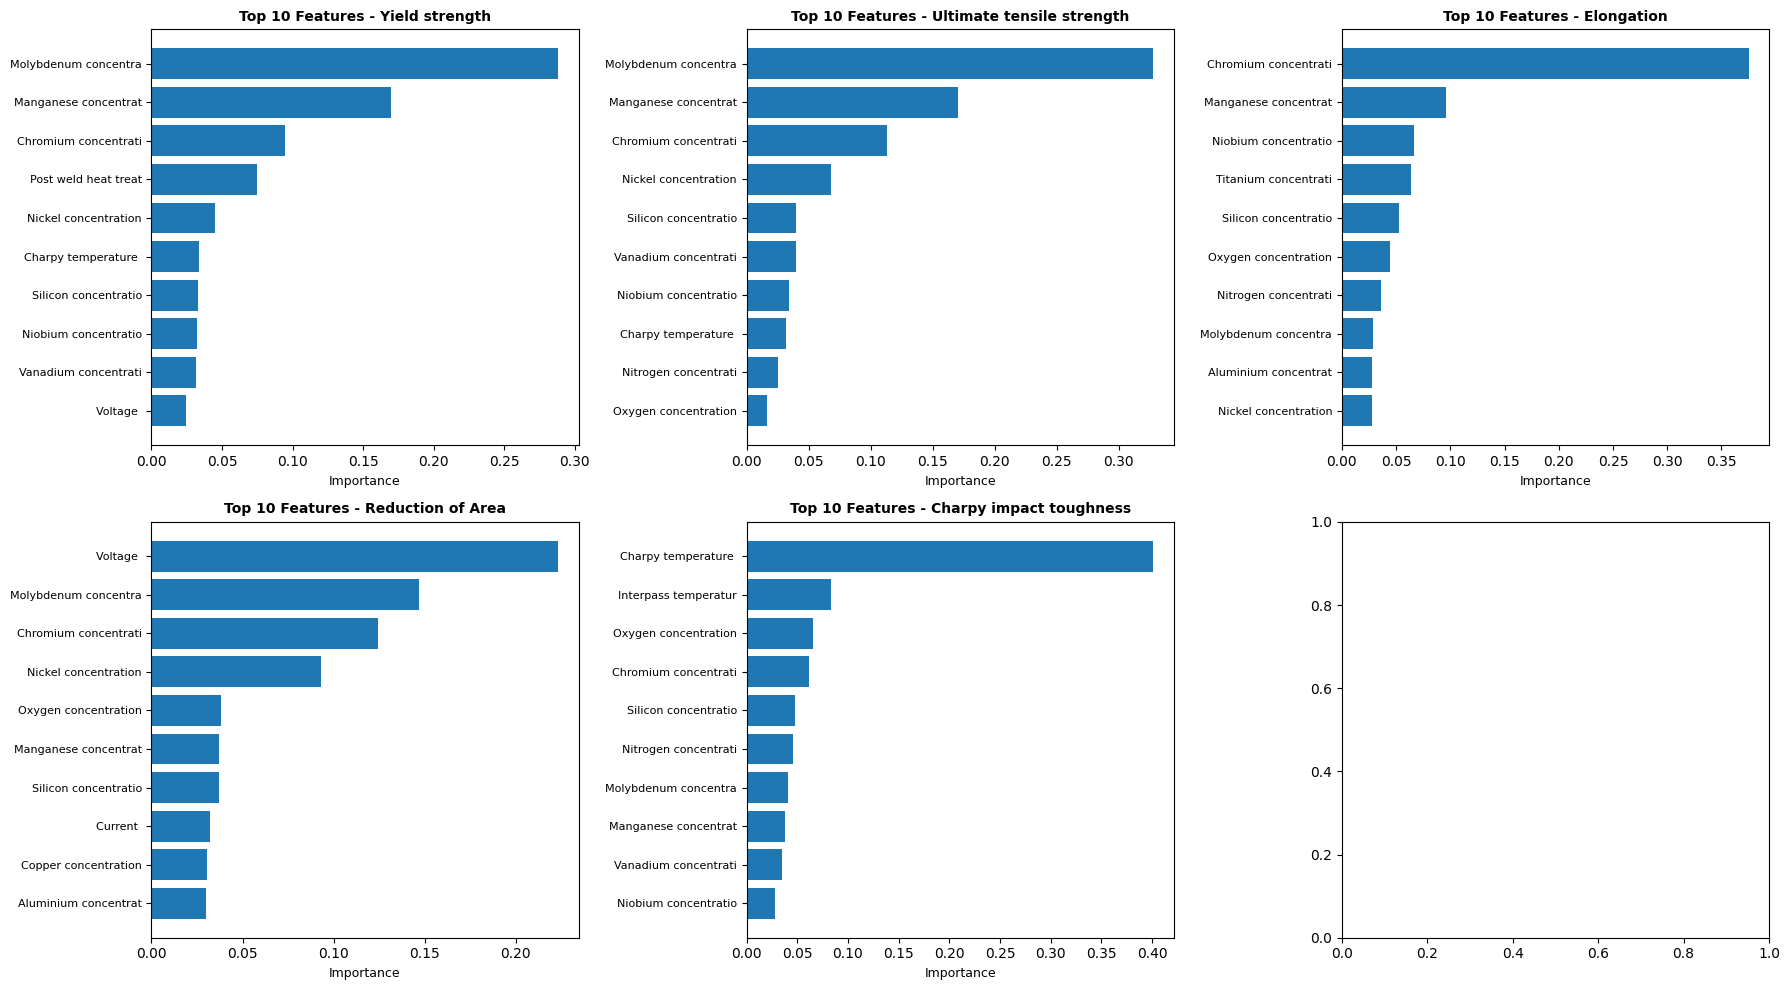

In [ ]:
# Extraire l'importance des features pour chaque modèle
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (target, res) in enumerate(all_results.items()):
    model = res['model']
    importances = model.feature_importances_

    # Top 10 features
    indices = np.argsort(importances)[-10:][::-1]
    top_features = [X.columns[i] for i in indices]
    top_importances = importances[indices]

    ax = axes[idx]
    ax.barh(range(len(top_features)), top_importances)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels([f.split('(')[0][:20] for f in top_features], fontsize=8)
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_title(f"Top 10 Features - {target.split('(')[0].strip()}",
                 fontsize=10, fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()